In [3]:
import pandas as pd
import numpy as np
import cdflib
import matplotlib.pyplot as plt


In [4]:
fp_mms1_moms="C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf"

In [5]:
fp_mms1_dist = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01//mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf"

#fp_mms1_moms = 'data/mms1/fpi/brst/l2/des-moms/2024/01/01/mms1_fpi_brst_l2_des-moms_20240101131913_v3.4.0.cdf'
#fp_mms4_dist = 'data/mms4/fpi/brst/l2/des-dist/2024/01/01/mms4_fpi_brst_l2_des-dist_20240101131913_v3.4.0.cdf'

with cdflib.CDF(fp_mms1_dist) as cdf_file:
    # Get the global attributes
    global_attributes = cdf_file.globalattsget()
    print("Attributes:")
    for attr, value in global_attributes.items():
        print(f"{attr}: {value}")

    # Get the variable names using cdf_info().rVariables and zVariables
    cdf_info = cdf_file.cdf_info()
    variables = cdf_info.rVariables + cdf_info.zVariables
    print("\nVariables:")
    for var in variables:
        print(var)

    # Get the attributes of each variable
    print("\nVariable Attributes:")
    for var in variables:
        var_attrs = cdf_file.varattsget(var)
        print(f"\nAttributes for {var}:")
        for attr, value in var_attrs.items():
            print(f"{attr}: {value}")

    # Get the data of each variable
    print("\nVariable Data Sizes:")
    for var in variables:
        data = cdf_file.varget(var)
        if type(data) == np.ndarray:
            print(f"{var}: {data.shape}")
        else:
            print(f"{var}: {data}")

Attributes:
Project: ['STP>Solar-Terrestrial Physics']
Source_name: ['MMS1>MMS Satellite Number 1']
Discipline: ['Space Physics>Magnetospheric Science']
Data_type: ['brst_l2_des-dist']
Descriptor: ['DES>Dual Electron Spectrometers']
File_naming_convention: ['source_descriptor_datatype_yyyyMMddHHmmss']
Data_version: ['3.4.0']
PI_name: ['J. Burch, B. Giles']
PI_affiliation: ['SwRI, GSFC']
TEXT: ['FPI usually operates in Fast Survey Mode in the MMS Region Of Interest (ROI) for the current Mission Phase.  Data are taken at burst (30/150 ms for DES/DIS) resolution in this mode.  Data are also made available at survey (4.5 s, etc) resolution; these form a separate product from this.  Per mission design, not all burst-resolution data are downlinked.  This product contains phase-space distribution maps of those burst-resolution data selected for downlink.  In particular, the (highest possible quality at the time of release) corrected/converted "Burst SkyMap" distributions are reported with tim

mms1_des_dist_brst: (4333, 32, 16, 32)
mms1_des_disterr_brst: (4333, 32, 16, 32)
mms1_des_avgf1counts_brst: (4333, 32)
mms1_des_steptimeoffsets_brst: (4333, 32, 16, 32)
mms1_des_sector_despinp_brst: (4333,)
mms1_des_sector_label_brst: (1, 32)
mms1_des_pixel_label_brst: (1, 16)
mms1_des_energy_label_brst: (1, 32)
mms1_des_theta_brst: (16,)
mms1_des_theta_delta_brst: (16,)
mms1_des_energy_brst: (4333, 32)
mms1_des_energy_delta_brst: (4333, 32)


In [6]:
dist_data = cdf_file.varget('mms1_des_dist_brst')
phi_data = cdf_file.varget('mms1_des_phi_brst')
theta_data = cdf_file.varget('mms1_des_theta_brst')
energy_data = cdf_file.varget('mms1_des_energy_brst')
epoch_data = cdf_file.varget('Epoch')

In [7]:
dist_data.shape, phi_data.shape, theta_data.shape, energy_data.shape, epoch_data.shape

((4333, 32, 16, 32), (4333, 32), (16,), (4333, 32), (4333,))

In [6]:
phi_data.shape

(4666, 32)

In [7]:
pd.DataFrame(energy_data)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,6.52,8.54,11.17,14.63,19.15,25.07,32.810001,42.950001,56.23,73.599998,...,2438.919922,3192.610107,4179.200195,5470.680176,7161.25,9374.25,12271.120117,16063.200195,21027.109375,27525.0
1,6.52,8.54,11.17,14.63,19.15,25.07,32.810001,42.950001,56.23,73.599998,...,2438.919922,3192.610107,4179.200195,5470.680176,7161.25,9374.25,12271.120117,16063.200195,21027.109375,27525.0
2,6.52,8.54,11.17,14.63,19.15,25.07,32.810001,42.950001,56.23,73.599998,...,2438.919922,3192.610107,4179.200195,5470.680176,7161.25,9374.25,12271.120117,16063.200195,21027.109375,27525.0
3,6.52,8.54,11.17,14.63,19.15,25.07,32.810001,42.950001,56.23,73.599998,...,2438.919922,3192.610107,4179.200195,5470.680176,7161.25,9374.25,12271.120117,16063.200195,21027.109375,27525.0
4,6.52,8.54,11.17,14.63,19.15,25.07,32.810001,42.950001,56.23,73.599998,...,2438.919922,3192.610107,4179.200195,5470.680176,7161.25,9374.25,12271.120117,16063.200195,21027.109375,27525.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4661,6.52,8.54,11.17,14.63,19.15,25.07,32.810001,42.950001,56.23,73.599998,...,2438.919922,3192.610107,4179.200195,5470.680176,7161.25,9374.25,12271.120117,16063.200195,21027.109375,27525.0
4662,6.52,8.54,11.17,14.63,19.15,25.07,32.810001,42.950001,56.23,73.599998,...,2438.919922,3192.610107,4179.200195,5470.680176,7161.25,9374.25,12271.120117,16063.200195,21027.109375,27525.0
4663,6.52,8.54,11.17,14.63,19.15,25.07,32.810001,42.950001,56.23,73.599998,...,2438.919922,3192.610107,4179.200195,5470.680176,7161.25,9374.25,12271.120117,16063.200195,21027.109375,27525.0
4664,6.52,8.54,11.17,14.63,19.15,25.07,32.810001,42.950001,56.23,73.599998,...,2438.919922,3192.610107,4179.200195,5470.680176,7161.25,9374.25,12271.120117,16063.200195,21027.109375,27525.0


Number density: As described earlier.
Bulk velocity: Weighted by the phase space density and integrated over energy, azimuth, and elevation.
Pressure tensor: Involves the second moment of the velocity distribution.
Entropy: Using specific integrals, possibly linked with entropy flux.

In [8]:
import sys
sys.path.append("C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//mmspy")

from moments import Moments

mom = Moments()


In [9]:
nen =energy_data.shape[1]  # energy_data is in shape (time, energy)


In [10]:
mom=Moments(nen_corrected=nen) # Initialize the Moments class with the number of energy bins

In [11]:
# timestep_index = 0
# fg = dist_data[timestep_index, :, :, :]  # Shape (nen, nth, nph) - phase space distribution

# # Set the energy levels for this timestep
# mom.energy_corrected = energy_data[timestep_index, :]  # Assuming shape (32,) for 32 energy bins

# # Loop through the energy levels and compute angle integrals for each one
# for i in range(fg.shape[0]):  # Loop over energy levels
#     fg_energy_level = fg[i, :, :]  # Shape (nth, nph) - single energy level distribution
    
#     # Compute angle integrals using the Moments class
#     theta_deg = theta_data  # Assuming this is 1D (shape (16,))
#     phi_deg = phi_data[timestep_index, :]  # Assuming shape (32,) for this timestep
    
#     # Compute the angle integrals for this energy level
#     integrals = mom.compute_angle_integrals(fg_energy_level, theta_deg, phi_deg)

#     # Store the computed angle integrals in the appropriate variables in the Moments class
#     mom.inttheta0[i] = integrals[0]
#     mom.inttheta1[i] = integrals[1]
#     mom.inttheta2[i] = integrals[2]
#     mom.inttheta3[i] = integrals[3]
#     mom.inttheta4[i] = integrals[4]
#     mom.inttheta5[i] = integrals[5]
#     mom.inttheta6[i] = integrals[6]
#     mom.inttheta7[i] = integrals[7]
#     mom.inttheta8[i] = integrals[8]
#     mom.inttheta9[i] = integrals[9]

# # Now, you can proceed to calculate the energy integrals based on these results
# mom.compute_energy_integrals()

# # After computation, print the moments
# print(f"Density = {mom.density}, vx = {mom.vx}, vy = {mom.vy}, vz = {mom.vz}")

Density = 168241.9498030058, vx = -61157.88147662828, vy = -20453.676123442132, vz = 1443.5222667234552


In [11]:
# Loop over all timesteps
# Initialize lists to store the moments for each timestep
densities = []
vx_list = []
vy_list = []
vz_list = []

# Loop over all timesteps
for t in range(len(dist_data)):
    # Initialize a new Moments instance for each timestep
    mom = Moments(nen_corrected=32)  # Adjust 'nen_corrected' as per your actual data
    
    fg = dist_data[t, :, :, :]  # Distribution function for this timestep
    mom.energy_corrected = energy_data[t, :]  # Set energy levels
    
    # Loop through the energy levels and compute angle integrals for each one
    for i in range(fg.shape[0]):  # Loop over energy levels
        fg_energy_level = fg[i, :, :]  # Shape (nth, nph) - single energy level distribution
        
        # Compute angle integrals for this energy level
        integrals = mom.compute_angle_integrals(fg_energy_level, theta_data, phi_data[t, :])
        # Check constants compute_angle_integrals
        
        # Store the computed angle integrals
        mom.inttheta0[i] = integrals[0]
        mom.inttheta1[i] = integrals[1]
        mom.inttheta2[i] = integrals[2]
        mom.inttheta3[i] = integrals[3]
        mom.inttheta4[i] = integrals[4]
        mom.inttheta5[i] = integrals[5]
        mom.inttheta6[i] = integrals[6]
        mom.inttheta7[i] = integrals[7]
        mom.inttheta8[i] = integrals[8]
        mom.inttheta9[i] = integrals[9]

    # Calculate energy integrals after computing angle integrals for all energy bins
    mom.compute_energy_integrals()
    # Check constants compute_angle_integrals

    # Store the moments for plotting later
    densities.append(mom.density)
    vx_list.append(mom.vx)
    vy_list.append(mom.vy)
    vz_list.append(mom.vz)




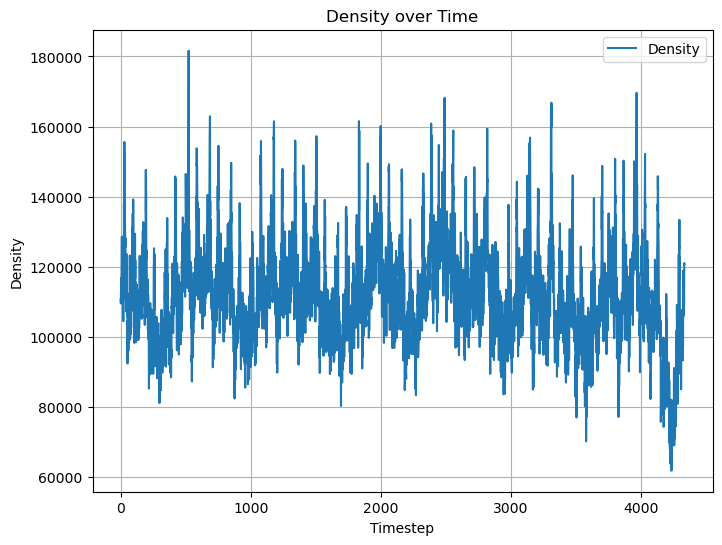

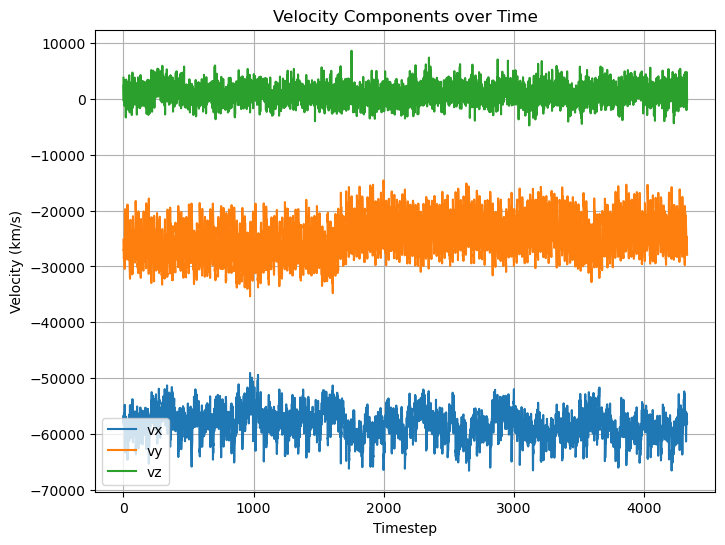

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(densities, label='Density')
plt.title('Density over Time')
plt.xlabel('Timestep')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# Plot the velocity components over time
plt.figure(figsize=(8, 6))
plt.plot(vx_list, label='vx')
plt.plot(vy_list, label='vy')
plt.plot(vz_list, label='vz')
plt.title('Velocity Components over Time')
plt.xlabel('Timestep')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid(True)
plt.show()

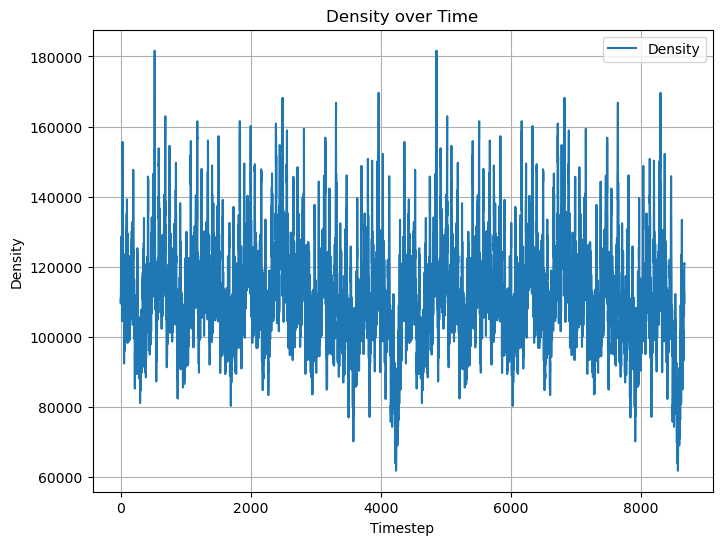

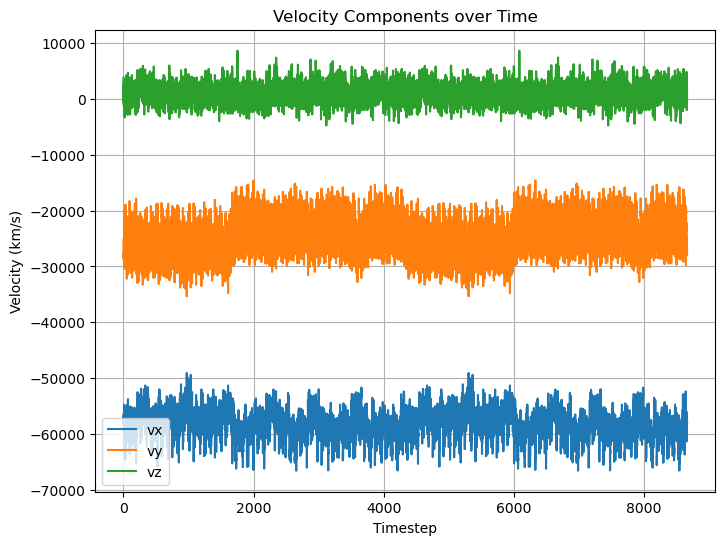

In [25]:

# Loop over all timesteps
for t in range(len(dist_data)):
    # Initialize a new Moments instance for each timestep
    nen = energy_data.shape[1]  # Assuming energy_data is in shape (time, energy)
    mom = Moments(nen_corrected=nen)  # Adjust 'nen_corrected' as per your actual data

    # Extract the distribution function for this timestep (shape: energy, theta, phi)
    fg = dist_data[t, :, :, :]

    # Set energy levels for the current timestep
    mom.energy_corrected = energy_data[t, :]

    # Loop through the energy levels and compute angle integrals for each one
    for i in range(fg.shape[0]):  # Loop over energy levels
        fg_energy_level = fg[i, :, :]  # Extract data for this energy level (shape: theta, phi)

        # Compute angle integrals for this energy level
        integrals = mom.compute_angle_integrals(fg_energy_level, theta_data, phi_data[t, :])

        # Store the computed angle integrals in the Moments instance
        mom.inttheta0[i] = integrals[0]
        mom.inttheta1[i] = integrals[1]
        mom.inttheta2[i] = integrals[2]
        mom.inttheta3[i] = integrals[3]
        mom.inttheta4[i] = integrals[4]
        mom.inttheta5[i] = integrals[5]
        mom.inttheta6[i] = integrals[6]
        mom.inttheta7[i] = integrals[7]
        mom.inttheta8[i] = integrals[8]
        mom.inttheta9[i] = integrals[9]

    # Calculate energy integrals after computing angle integrals for all energy bins
    mom.compute_energy_integrals()

    # Store the computed moments for plotting later
    densities.append(mom.density)
    vx_list.append(mom.vx)
    vy_list.append(mom.vy)
    vz_list.append(mom.vz)

# Plot the calculated density over time
plt.figure(figsize=(8, 6))
plt.plot(densities, label='Density')
plt.title('Density over Time')
plt.xlabel('Timestep')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

# Plot the velocity components over time
plt.figure(figsize=(8, 6))
plt.plot(vx_list, label='vx')
plt.plot(vy_list, label='vy')
plt.plot(vz_list, label='vz')
plt.title('Velocity Components over Time')
plt.xlabel('Timestep')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid(True)
plt.show()

In [17]:

with cdflib.CDF(fp_mms1_moms) as cdf_file:
    # Get the global attributes
    global_attributes = cdf_file.globalattsget()
    print("Attributes:")
    for attr, value in global_attributes.items():
        print(f"{attr}: {value}")

    # Get the variable names using cdf_info().rVariables and zVariables
    cdf_info = cdf_file.cdf_info()
    variables = cdf_info.rVariables + cdf_info.zVariables
    print("\nVariables:")
    for var in variables:
        print(var)

    # Get the attributes of each variable
    print("\nVariable Attributes:")
    for var in variables:
        var_attrs = cdf_file.varattsget(var)
        print(f"\nAttributes for {var}:")
        for attr, value in var_attrs.items():
            print(f"{attr}: {value}")

    # Get the data of each variable
    print("\nVariable Data Sizes:")
    for var in variables:
        data = cdf_file.varget(var)
        if type(data) == np.ndarray:
            print(f"{var}: {data.shape}")
        else:
            print(f"{var}: {data}")

Attributes:
Project: ['STP>Solar-Terrestrial Physics']
Source_name: ['MMS1>MMS Satellite Number 1']
Discipline: ['Space Physics>Magnetospheric Science']
Data_type: ['brst_l2_des-moms']
Descriptor: ['DES>Dual Electron Spectrometers']
File_naming_convention: ['source_descriptor_datatype_yyyyMMddHHmmss']
Data_version: ['3.4.0']
PI_name: ['J. Burch, B. Giles']
PI_affiliation: ['SwRI, GSFC']
TEXT: ['FPI usually operates in Fast Survey (FS) Mode in the MMS Region Of Interest (ROI) for the current Mission Phase.  Data are taken at burst (30/150 ms for DES/DIS) resolution in this mode.  Data are also made available at survey (4.5 s, etc) resolution.  Per mission design, not all burst-resolution data are downlinked, but all survey data are downlinked.  Planning around calibration activities, avoidance of Earth radiation belts, etc, when possible, FPI usually operates in Slow Survey (SS) Mode outside of ROI, and then only the 60 s resolution survey data are available.  This product contains resu

In [18]:
with cdflib.CDF(fp_mms1_moms) as cdf_file:
    density_l2 = cdf_file.varget('mms1_des_numberdensity_brst')
    bulk_velocity_l2 = cdf_file.varget('mms1_des_bulkv_gse_brst')  # GSE velocity components

# Extract the velocity components
vx_l2, vy_l2, vz_l2 = bulk_velocity_l2[:, 0], bulk_velocity_l2[:, 1], bulk_velocity_l2[:, 2]

In [23]:
# vx_l2, vx_list, density_l2, densities
density_l2

array([ 8.591805 ,  8.573184 ,  8.5806465, ..., 11.558542 , 11.4973345,
       11.472048 ], dtype=float32)